In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os, json, random
from collections import Counter

I0000 00:00:1781812997.451688 2963408 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Check image path

omama_dir_path = "/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images"
if not os.path.exists(omama_dir_path):
    print(f"File not found: {omama_dir_path}")
    print("Please update dicom_path with a valid image file path")
else:
    print(f"Found DICOM folder: {os.path.basename(omama_dir_path)}")
    omama_folder = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/images")
    IDs = sorted(str(file) for file in omama_folder.rglob("*.npz"))
    print(len(IDs))

Found DICOM folder: images
163568


In [4]:
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/2d_resized_256/metadata")

In [5]:
# Get the images and labels
all_images = []
all_labels = []
all_ids = {}

for ID in IDs :
    meta = json.load(open(meta_dir / f"{Path(ID).stem}.json"))
    if meta["PatientID"] not in all_ids.keys() :
        all_ids[meta["PatientID"]] = 1
    else : 
        continue
    if meta["label"] == "NonCancer" :
        all_labels.append(0)
    elif meta["label"] == "Unknown" :
        continue
    elif meta["label"] == "IndexCancer" or meta["label"] == "PreIndexCancer" : 
        all_labels.append(1)
    else : 
        continue
    img = np.load(ID)['data']
    img = np.expand_dims(img, axis=-1)
    all_images.append(img)

In [6]:
# Shuffle (image, label) order
combined = list(zip(all_images, all_labels))
random.shuffle(combined)
all_images, all_labels = zip(*combined)
all_labels = np.array(all_labels, dtype=np.float32)
print(Counter(all_labels.astype(int)))

Counter({np.int64(0): 154238, np.int64(1): 2599})


In [7]:
# Create balanced dataset
nc_images = []
nc_labels = []
c_images = []
c_labels = []
NonCancer = 0
Cancer = 0
for img, label in zip(all_images, all_labels) :
    if NonCancer == 2599 and Cancer == 2599 :
        break
    if NonCancer < 2599 and label == 0 :
        nc_images.append(img)
        nc_labels.append(label)
        NonCancer += 1
    elif Cancer < 2599 and label == 1 :
        c_images.append(img)
        c_labels.append(label)
        Cancer += 1
nc_images = np.array(nc_images, dtype=np.float32)
nc_labels = np.array(nc_labels, dtype=np.float32)
c_images = np.array(c_images, dtype=np.float32)
c_labels = np.array(c_labels, dtype=np.float32)

print(Counter(nc_labels.astype(int)))
print(Counter(c_labels.astype(int)))

Counter({np.int64(0): 2599})
Counter({np.int64(1): 2599})


In [8]:
# Split data

train_size = int(0.7 * len(nc_images)) 
val_size = int(0.15 * len(nc_images))
test_size = int(0.15 * len(nc_images))

train_images = np.concatenate([nc_images[:train_size], c_images[:train_size]], axis=0)
val_images = np.concatenate([nc_images[train_size:val_size + train_size], c_images[train_size:val_size + train_size]], axis=0)
test_images = np.concatenate([nc_images[val_size + train_size:val_size + train_size + test_size], c_images[val_size + train_size:val_size + train_size + test_size]], axis=0)

train_labels = np.concatenate([nc_labels[:train_size], c_labels[:train_size]], axis=0)
val_labels = np.concatenate([nc_labels[train_size:val_size + train_size], c_labels[train_size:val_size + train_size]], axis=0)
test_labels = np.concatenate([nc_labels[val_size + train_size:val_size + train_size + test_size], c_labels[val_size + train_size:val_size + train_size + test_size]], axis=0)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"Train: {len(train_labels)}, Val: {len(val_labels)}, Test: {len(test_labels)}")


Train: 3638, Val: 778, Test: 778
Train: 3638, Val: 778, Test: 778


In [9]:
print("train", Counter(train_labels.astype(int)))
print("val", Counter(val_labels.astype(int)))
print("test", Counter(test_labels.astype(int)))

train Counter({np.int64(0): 1819, np.int64(1): 1819})
val Counter({np.int64(0): 389, np.int64(1): 389})
test Counter({np.int64(0): 389, np.int64(1): 389})


In [10]:
# Check the distribution of classes
print(f'Average class probability in training set:   {train_labels.mean():.4f}')
print(f'Average class probability in validation set: {val_labels.mean():.4f}')
print(f'Average class probability in test set:       {test_labels.mean():.4f}')

Average class probability in training set:   0.5000
Average class probability in validation set: 0.5000
Average class probability in test set:       0.5000


In [11]:
# Check dimension size and color channel
print("Shape:", all_images[0].shape)

Shape: (256, 256, 1)


In [12]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.shuffle(len(train_labels)).batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.batch(32)

I0000 00:00:1781813132.351081 2963408 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:bd:00.0, compute capability: 8.0


In [13]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [14]:
# Import pretrained model
base_model = tf.keras.applications.ResNet50(input_shape=(256, 256, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [15]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
# Convert image tensor from 1 channel to 3 for the model
inputs = tf.keras.Input(shape=(256, 256, 1))
x = tf.keras.layers.Concatenate()([inputs, inputs, inputs])

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs, outputs) # wrap all layers

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ concatenate[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ]
)

In [19]:
initial_epochs = 20
history = model.fit(train_ds, epochs=initial_epochs, validation_data = val_ds)

Epoch 1/20


I0000 00:00:1781813143.647194 2965947 service.cc:153] XLA service 0x7f3f440689e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781813143.647225 2965947 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-40GB, Compute Capability 8.0 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1781813143.803362 2965947 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781813145.124655 2965947 cuda_dnn.cc:461] Loaded cuDNN version 92302


  7/114 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - auc: 0.4573 - loss: 0.7911

I0000 00:00:1781813156.068952 2965947 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - auc: 0.6206 - loss: 0.6864 - val_auc: 0.6894 - val_loss: 0.6303
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - auc: 0.6834 - loss: 0.6427 - val_auc: 0.7100 - val_loss: 0.6202
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - auc: 0.7139 - loss: 0.6166 - val_auc: 0.7121 - val_loss: 0.6337
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - auc: 0.7268 - loss: 0.6063 - val_auc: 0.7197 - val_loss: 0.6157
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - auc: 0.7430 - loss: 0.5927 - val_auc: 0.7149 - val_loss: 0.6182
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - auc: 0.7474 - loss: 0.5891 - val_auc: 0.7253 - val_loss: 0.6128
Epoch 7/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - auc: 0.7533 - loss: 0.5828 - val_auc: 0.7261 - val_loss: 0.6103
Epoch 8/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - auc: 0.7625 - loss: 0.5765 - val_auc: 0.7261 - val_loss: 0.6143
Epoch 9/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - au

In [20]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [21]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 50

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ concatenate[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,861 (90.00 MB)

 Trainable params: 16,952,577 (64.67 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

 Optimizer params: 4,100 (16.02 KB)

In [23]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ],
)

In [24]:
# Train the model
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds)

Epoch 21/30


Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


114/114 ━━━━━━━━━━━━━━━━━━━━ 53s 234ms/step - auc_1: 0.7449 - loss: 0.6491 - val_auc_1: 0.7189 - val_loss: 0.6831
Epoch 22/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - auc_1: 0.8769 - loss: 0.4341 - val_auc_1: 0.7156 - val_loss: 0.6758
Epoch 23/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - auc_1: 0.9538 - loss: 0.3016 - val_auc_1: 0.7161 - val_loss: 0.7244
Epoch 24/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - auc_1: 0.9855 - loss: 0.2083 - val_auc_1: 0.7238 - val_loss: 0.7315
Epoch 25/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - auc_1: 0.9968 - loss: 0.1371 - val_auc_1: 0.7148 - val_loss: 0.7782
Epoch 26/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - auc_1: 0.9991 - loss: 0.0962 - val_auc_1: 0.7089 - val_loss: 0.8559
Epoch 27/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - auc_1: 0.9998 - loss: 0.0610 - val_auc_1: 0.7142 - val_loss: 0.8779
Epoch 28/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - auc_1: 1.0000 - loss: 0.0414 - val_auc_1: 0.7177 - val_loss: 0.9062
Epoch 29/30
114/11

In [25]:
# Evaluate model
model.evaluate(test_ds)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - auc_1: 0.7256 - loss: 0.9600


[0.9599537253379822, 0.7256032824516296]

In [26]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step


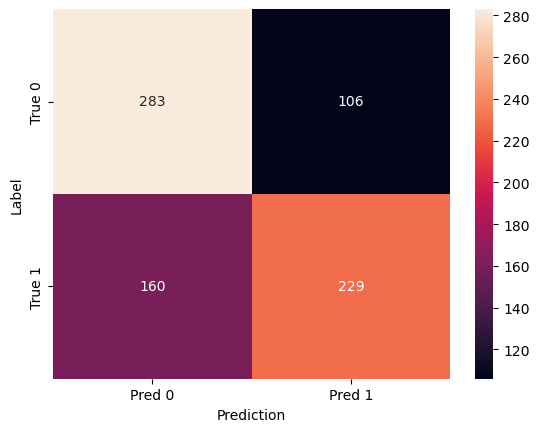

In [27]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

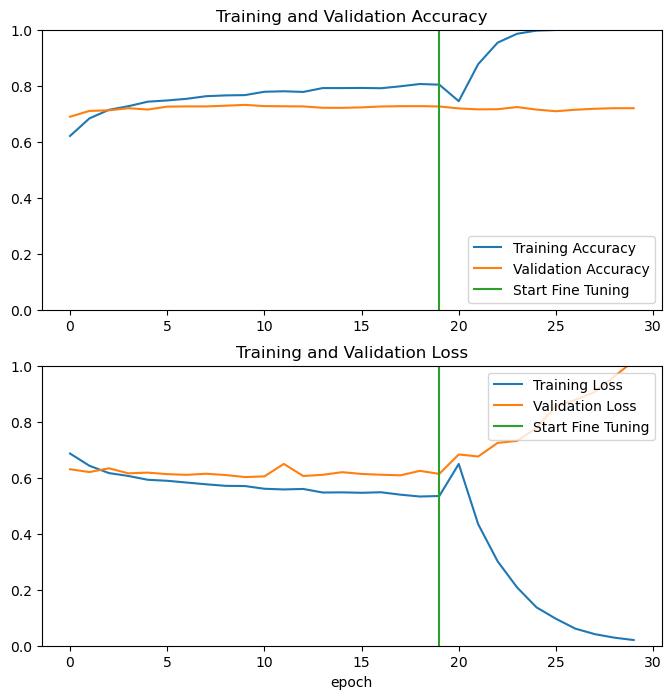

In [29]:
# Combine both for plotting
acc = history.history['auc'] + history_fine.history['auc_1']
val_acc = history.history['val_auc'] + history_fine.history['val_auc_1']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()